# Labeled 2D Histograms

This notebook loads the per-label histogram file written by `batch-labeled` and draws one 2D histogram per label.

- normal buckets: `0 peak`, `1 peak`, `2 peak`, `3 peak`, `4+ peaks`
- strange labels: one panel per strange label name
- each panel uses the same log-scaled color range for comparison
- interactive synchronized markers require an interactive Matplotlib backend such as `%matplotlib widget`


In [1]:
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

%matplotlib widget

workspace = Path("/data/rcnp2025/trace_label")
hist_file = workspace / "run_1056_labeled_hist2d.npy"
print(hist_file)
print(f"matplotlib backend: {plt.get_backend()}")


/data/rcnp2025/trace_label/run_1056_labeled_hist2d.npy
matplotlib backend: widget


In [2]:
payload = np.load(hist_file, allow_pickle=True).item()
label_titles = payload["label_titles"]
histograms = payload["histograms"]
trace_counts = payload["trace_counts"]

if histograms.ndim != 3 or histograms.shape[1:] != (150, 100):
    raise ValueError(f"expected histogram shape (num_labels, 150, 100), got {histograms.shape}")

print(label_titles.tolist())
print(trace_counts.tolist())


['0 peak', '1 peak', '2 peak', '3 peak', '4+ peaks', 'fat', 'oscillation', 'out', 'pileup', 'reverse', 'reverse_and_peak', 'saturation']
[629, 1006, 104, 12, 7, 75, 38, 8, 61, 17, 27, 77]


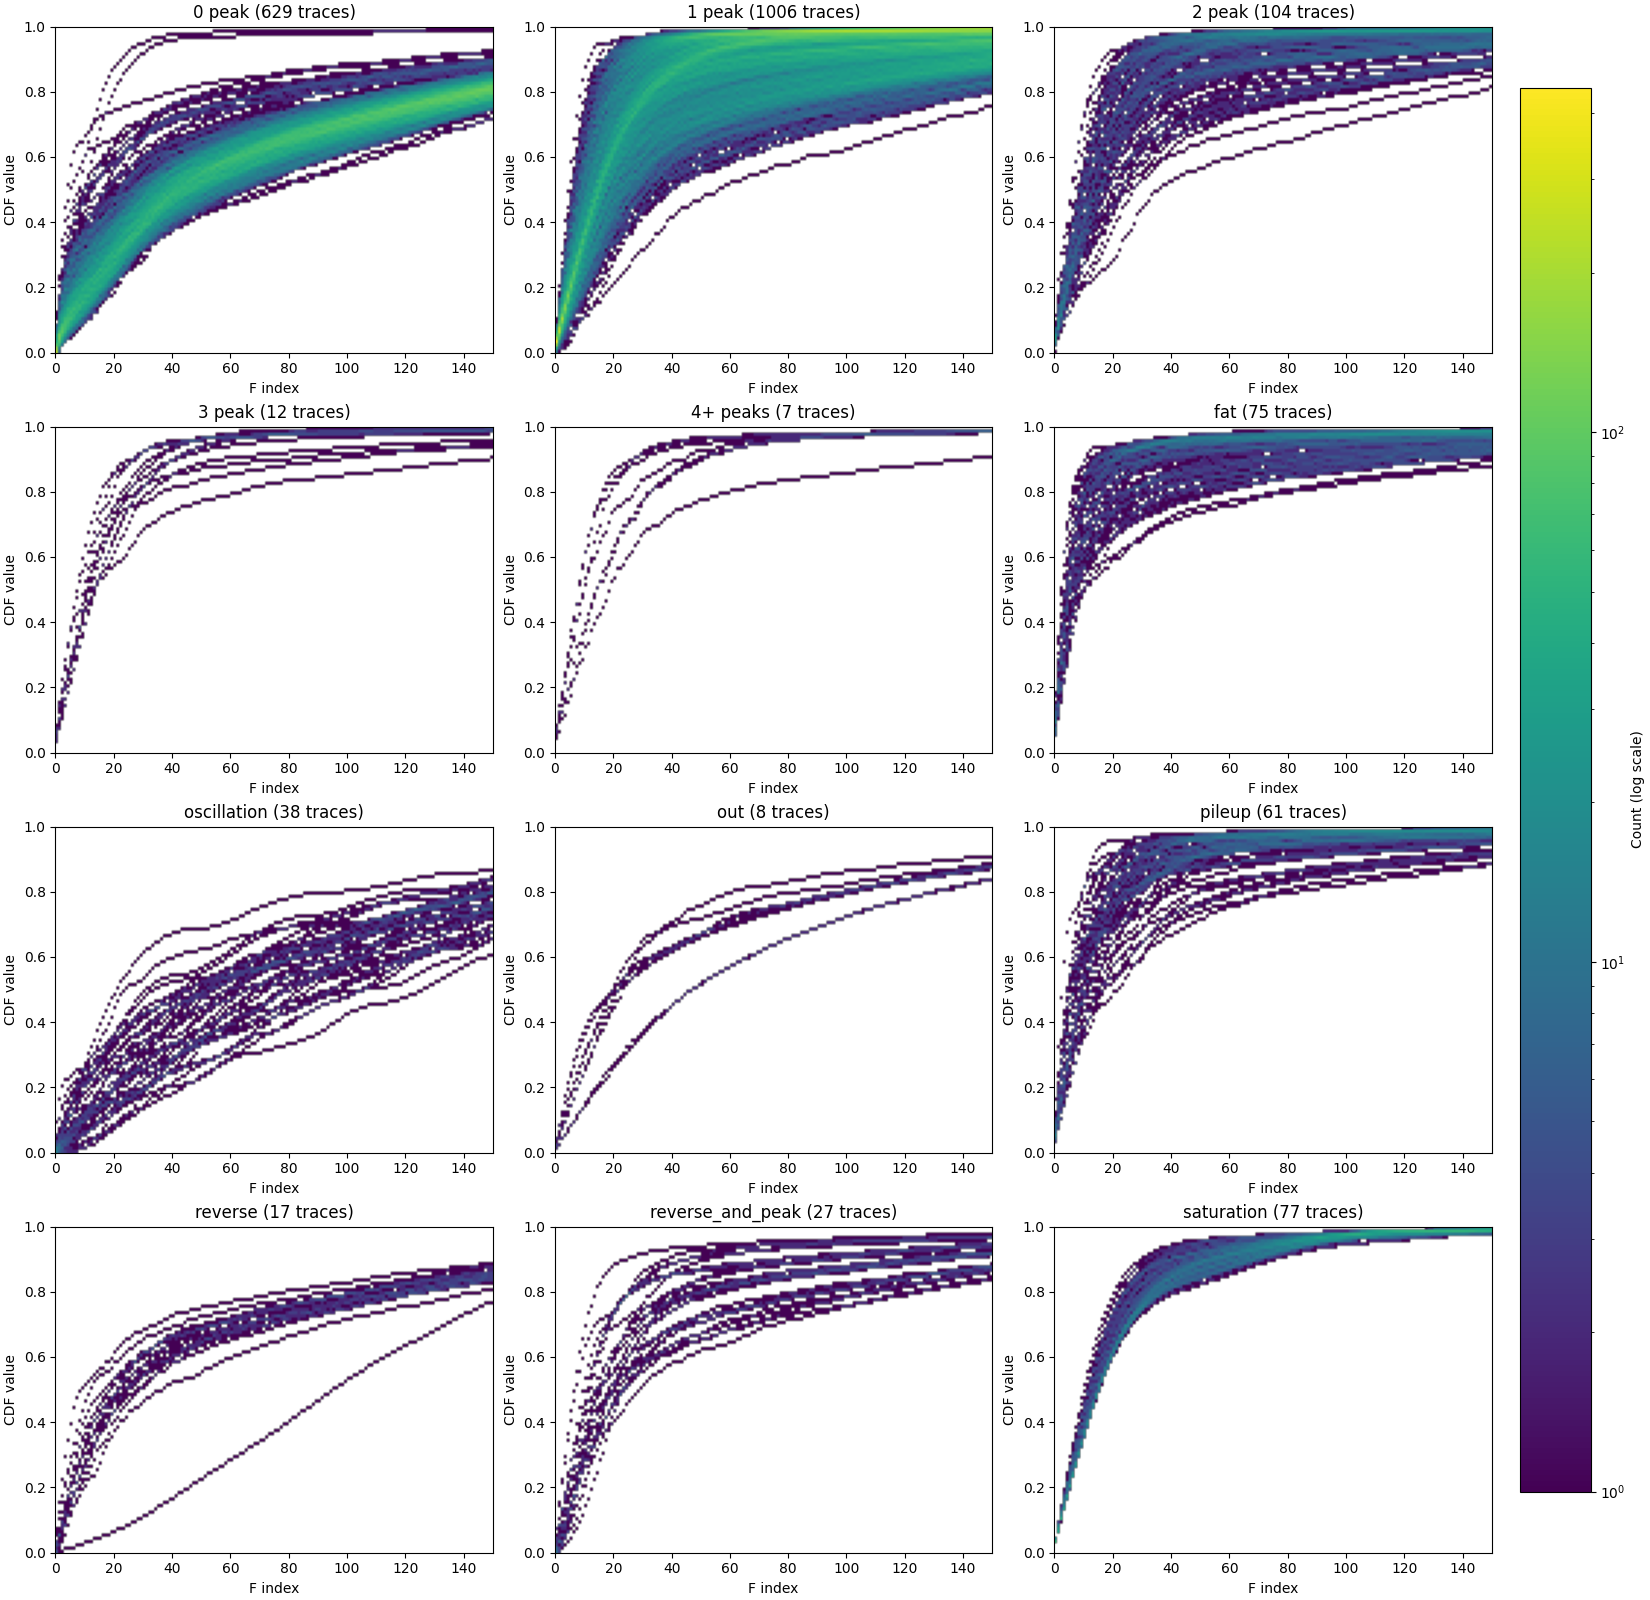

In [3]:
columns = 3
rows = ceil(len(label_titles) / columns)
fig, axes = plt.subplots(rows, columns, figsize=(5.5 * columns, 4.0 * rows), squeeze=False, constrained_layout=True)
axes_flat = axes.ravel()
visible_axes = axes_flat[: len(label_titles)]
positive = histograms[histograms > 0]
vmin = float(positive.min()) if positive.size else 1.0
norm = LogNorm(vmin=vmin, vmax=max(vmin, float(histograms.max()), 1.0))
image = None
cursor_artists = []

for index, (title, histogram, trace_count) in enumerate(zip(label_titles, histograms, trace_counts)):
    ax = visible_axes[index]
    image = ax.imshow(
        histogram.T,
        origin="lower",
        aspect="auto",
        extent=[0.0, 150.0, 0.0, 1.0],
        cmap="viridis",
        norm=norm,
    )
    ax.set_title(f"{title} ({int(trace_count)} traces)")
    ax.set_xlabel("F index")
    ax.set_ylabel("CDF value")
    ax.set_xlim(0.0, 150.0)
    ax.set_ylim(0.0, 1.0)

    vertical = ax.axvline(0.0, color="#111111", linestyle="--", linewidth=1.0, alpha=0.95, visible=False)
    horizontal = ax.axhline(0.0, color="#111111", linestyle="--", linewidth=1.0, alpha=0.95, visible=False)
    marker, = ax.plot([], [], marker="o", markersize=6, markerfacecolor="#ffcc00", markeredgecolor="#111111", markeredgewidth=1.2, linestyle="None", visible=False)
    cursor_artists.append((vertical, horizontal, marker))

for ax in axes_flat[len(label_titles):]:
    ax.set_visible(False)

if image is not None:
    colorbar = fig.colorbar(image, ax=visible_axes.tolist(), location="right", shrink=0.92, pad=0.02)
    colorbar.set_label("Count (log scale)")


def _set_cursor_visible(visible: bool) -> None:
    for vertical, horizontal, marker in cursor_artists:
        vertical.set_visible(visible)
        horizontal.set_visible(visible)
        marker.set_visible(visible)


def _update_cursor(event) -> None:
    if event.inaxes not in visible_axes or event.xdata is None or event.ydata is None:
        _set_cursor_visible(False)
        fig.canvas.draw_idle()
        return

    x = float(event.xdata)
    y = float(event.ydata)
    for vertical, horizontal, marker in cursor_artists:
        vertical.set_xdata([x, x])
        horizontal.set_ydata([y, y])
        marker.set_data([x], [y])
    _set_cursor_visible(True)
    fig.canvas.draw_idle()


def _clear_cursor(_event) -> None:
    _set_cursor_visible(False)
    fig.canvas.draw_idle()


fig.canvas.mpl_connect("motion_notify_event", _update_cursor)
fig.canvas.mpl_connect("figure_leave_event", _clear_cursor)

plt.show()
